# Linear Regression Gradient Verification

### 1. The Statistical Framework & Loss Definition

The model frames simple linear regression as a mapping from a single continuous independent feature vector $X$ to a continuous target scalar $y$ via a linear hypothesis function:

$$y_{\text{pred}} = wX + b$$

Where:
* **$w$ (Weight):** Represents the slope parameter, dictating the impact of $X$ on the target outcome.
* **$b$ (Bias):** Represents the intercept parameter, establishing the baseline response when input features equal zero.

To evaluate model accuracy across a training collection of $n$ unique examples, we implement the **Mean Squared Error (MSE)** loss function ($J$):

$$J(w, b) = \frac{1}{n} \sum_{i=1}^{n} \left( y^{(i)} - (wX^{(i)} + b) \right)^2$$

This metric calculates the average squared residual length. The squaring operation handles two key mathematical constraints: it ensures negative prediction errors do not cancel out positive errors, and it heavily penalizes larger errors to enforce a smooth, convex error surface.



In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# ====================================
# MODULE :1 MSE LOSS
# ====================================

def MSE_loss(y,y_pred):
    #Mean squared error 
    mse=np.mean((y-y_pred)**2)
    return mse
    


### 2. Analytical Gradient Formulation (Calculus)

To optimize parameters via Gradient Descent, we evaluate how the loss function changes with respect to both $w$ and $b$. This is achieved by computing the partial derivatives of $J(w, b)$ using the calculus **Chain Rule**.

#### Derivation for Weight Gradient ($\frac{\partial J}{\partial w}$):
$$\frac{\partial J}{\partial w} = \frac{\partial}{\partial w} \left[ \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - y_{\text{pred}}^{(i)})^2 \right]$$

Applying the power rule and multiplying by the derivative of the inner function with respect to $w$ (where $\frac{\partial}{\partial w}[y^{(i)} - (wX^{(i)} + b)] = -X^{(i)}$):

$$\frac{\partial J}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} 2(y^{(i)} - y_{\text{pred}}^{(i)}) \cdot (-X^{(i)})$$

$$\frac{\partial J}{\partial w} = -\frac{2}{n} \sum_{i=1}^{n} X^{(i)} (y^{(i)} - y_{\text{pred}}^{(i)})$$

#### Derivation for Bias Gradient ($\frac{\partial J}{\partial b}$):
Similarly, differentiating with respect to $b$ (where $\frac{\partial}{\partial b}[y^{(i)} - (wX^{(i)} + b)] = -1$):

$$\frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} 2(y^{(i)} - y_{\text{pred}}^{(i)}) \cdot (-1)$$

$$\frac{\partial J}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y^{(i)} - y_{\text{pred}}^{(i)})$$

These formal calculus derivations yield the exact steepness of the error bowl at any coordinate and map directly to the variables `dw` and `db` in the `mse_gradient` function.

---


In [3]:
# ============================================
# MODULE : 2 GRADIENT DECENT (USING CALCULUS)
# ============================================

def MSE_gradient_decent(y,X,w,b):
    #Number of training data
    n=len(y)
    
    #predicted y
    y_pred= w*X+b
    
    #Rate of chnage of W when b is constant i.e partial derivative
    dw = -(2/n)*np.sum(X*(y-y_pred))
    
    #Rate of chnage of b when w is constant i.e. partial derivative
    db=-(2/n)*np.sum(y-y_pred)
    
    return dw,db 

    



### 3. Numerical Gradient Approximation (The Manual Nudge)

Analytical code formulas are prone to subtle execution bugs or algebraic typos. To audit the derivative code, we approximate the slope at a given coordinate using a non-calculus geometric alternative called the **Symmetric Difference Quotient**.

Instead of computing an analytical tangent line, the algorithm moves the parameter forward and backward by an incredibly tiny step size, **$\epsilon$ (Epsilon)**, and measures the height difference on the error curve:

$$f'(w) \approx \frac{J(w + \epsilon, b) - J(w - \epsilon, b)}{2\epsilon}$$

#### The Mathematical Proof of Accuracy (Taylor Series Expansion)
To understand why this specific dual-sided step is highly accurate, we inspect the underlying function expansion around point $w$:

1. **Right-Hand Step:** $J(w + \epsilon) = J(w) + \epsilon J'(w) + \frac{\epsilon^2}{2!} J''(w) + \frac{\epsilon^3}{3!} J'''(w) + \mathcal{O}(\epsilon^4)$
2. **Left-Hand Step:** $J(w - \epsilon) = J(w) - \epsilon J'(w) + \frac{\epsilon^2}{2!} J''(w) - \frac{\epsilon^3}{3!} J'''(w) + \mathcal{O}(\epsilon^4)$

Subtracting the left-hand equation from the right-hand equation ($J(w + \epsilon) - J(w - \epsilon)$) provides an elegant algebraic cancellation:
* The baseline loss values cancel out: $J(w) - J(w) = 0$
* The **quadratic error terms cancel out perfectly**: $\frac{\epsilon^2}{2} J''(w) - \frac{\epsilon^2}{2} J''(w) = 0$

This isolates the first derivative component:
$$J(w + \epsilon) - J(w - \epsilon) = 2\epsilon J'(w) + \frac{2\epsilon^3}{6} J'''(w) + \dots$$

Dividing both sides by the total window interval ($2\epsilon$) yields:
$$\frac{J(w + \epsilon) - J(w - \epsilon)}{2\epsilon} = J'(w) + \mathcal{O}(\epsilon^2)$$

This guarantees that the approximation error is bounded by $\epsilon^2$. Given the code parameters where $\epsilon = 10^{-7}$, our numerical baseline approximation error matches an exceptionally tight scale of $(10^{-7})^2 = 10^{-14}$.



In [4]:
# ============================================
# MODULE : 3 NUMERICAL GRADIENT
# ============================================


def numerical_gradient(y,X,w,b,esp=1e-7):
   
    #Rate of change of w when b is consant
    loss_plus_w = MSE_loss(y,(w+esp)*X+b)
    loss_mins_w = MSE_loss(y,(w-esp)*X+b)
    dw_n=(loss_plus_w - loss_mins_w)/(2*esp)
    
    #Rate of change of b when w is consant
    loss_plus_b = MSE_loss(y,w*X + (b+esp))
    loss_mins_b = MSE_loss(y,w*X+(b-esp))
    db_n=(loss_plus_b - loss_mins_b)/(2*esp)
    
    return dw_n,db_n

    



### 4. Gradient Checking & Verification Protocol

The primary purpose of the script is to run a comparative verification test. By establishing an arbitrary baseline guess (`w_test = 1.5`), the program generates:
1. **`dw_analytical`**: The instantaneous slope computed via the calculus shortcut.
2. **`dw_numerical`**: The verified physical slope evaluated through the symmetric nudge.

The script evaluates accuracy using an absolute difference check:

$$\text{Difference} = \vert{} \text{dw\_analytical} - \text{dw\_numerical} \vert{}$$

* If $\text{Difference} \le 10^{-7}$, the analytical calculus code is verified as completely bug-free.
* If $\text{Difference} \ge 10^{-3}$, a mathematical typo or execution error is present inside the analytical derivative block.


In [5]:
# ============================================
# MODULE : 4 SYNTHETICALY GENERATED DATA 
# ============================================

#True w and b 
w,b=2,1

#single feature values
np.random.seed(56)
X = np.linspace(0,10,20)

#Adding noise in X
noise=np.random.normal(0,0.5,size=len(X))

#Actual vlaues of y 
y= w*X + b +noise 


In [19]:
# ============================================
# MODULE : 5 TEST CASES 
# ============================================

#initialise with different weight(w) and intercept(b)
w_test,b_test = 1.5,1

#using calculus
dw_analytical,db_analytical=MSE_gradient_decent(y,X,w_test,b_test)

#Using Numerical nudge
dw_numerical,db_numerical = numerical_gradient(y,X,w_test,b_test)


print(f"Analytical dw: {dw_analytical:.6f}")
print(f"Numerical dw:  {dw_numerical:.6f}")

if abs(dw_analytical - dw_numerical) < 1e-6:
    print("The analytical and numerical gradients are approximately equal.")
else:
    print("The analytical and numerical gradients are not equal.")
    
print("--"*40)
    
print(f"Analytical db: {db_analytical:.6f}")
print(f"Numerical db:  {db_numerical:.6f}")

if abs(db_analytical - db_numerical) < 1e-7:
    print("The analytical and numerical gradients are approximately equal.")
else:
    print("The analytical and numerical gradients are not equal.")


Analytical dw: -35.324490
Numerical dw:  -35.324490
The analytical and numerical gradients are approximately equal.
--------------------------------------------------------------------------------
Analytical db: -5.128334
Numerical db:  -5.128334
The analytical and numerical gradients are approximately equal.


Optimal w: 2.02 with MSE Loss: 0.2321
Actual w :2
----------------------------------------
Optimal b: 1.04 with MSE Loss: 0.2370
Actual b:1


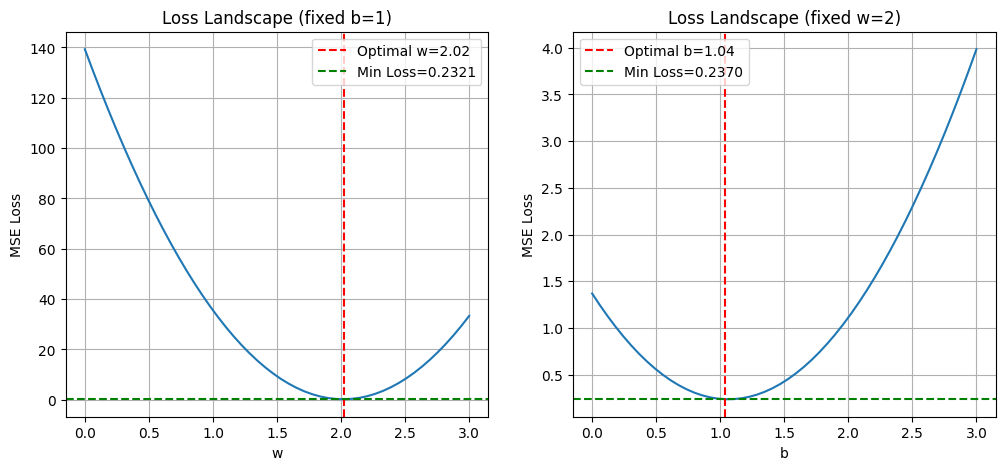

In [24]:
w_vals = np.linspace(0, 3, 50)
losses = [MSE_loss(y, w*X + 1.0) for w in w_vals]  # fix b=1


b_vals = np.linspace(0,3,50)
losses_b = [MSE_loss(y,2*X+b) for b in b_vals ] # fix w=2


#finding the mimum loss and corresponding w and b
min_loss_w = min(losses)
optimal_w = w_vals[losses.index(min_loss_w)]

min_loss_b = min(losses_b)
optimal_b = b_vals[losses_b.index(min_loss_b)]

print(f"Optimal w: {optimal_w:.2f} with MSE Loss: {min_loss_w:.4f}")
print(f"Actual w :{w}")

print("--"*20)
print(f"Optimal b: {optimal_b:.2f} with MSE Loss: {min_loss_b:.4f}")
print(f"Actual b:{b}")            



ax,fig=plt.subplots(1,2,figsize=(12,5))
fig[0].plot(w_vals, losses)
fig[0].set_xlabel('w')
fig[0].set_ylabel('MSE Loss')
fig[0].set_title('Loss Landscape (fixed b=1)')
fig[0].axvline(optimal_w, color='r', linestyle='--', label=f'Optimal w={optimal_w:.2f}')
fig[0].axhline(min_loss_w ,color='g', linestyle='--', label=f'Min Loss={min_loss_w:.4f}')
fig[0].legend()
fig[0].grid(True)
       
fig[1].plot(b_vals, losses_b)
fig[1].set_xlabel('b')
fig[1].set_ylabel('MSE Loss')
fig[1].set_title('Loss Landscape (fixed w=2)')
fig[1].axvline(optimal_b, color='r', linestyle='--', label=f'Optimal b={optimal_b:.2f}')
fig[1].axhline(min_loss_b ,color='g', linestyle='--', label=f'Min Loss={min_loss_b:.4f}')
fig[1].legend()
fig[1].grid(True)
plt.show()

